# Projet 9 - Mise en place d'un système RAG

#### Liste des imports du projet

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)   # affiche toutes les colonnes
pd.set_option('display.max_rows', 100)        # affiche jusqu'à 100 lignes (ajuste selon besoin)
pd.set_option('display.width', None)          # n'impose pas de largeur max, s'adapte au contenu
pd.set_option('display.max_colwidth', None)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import torch
import langchain
import mistralai
import os

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from mistralai.client import Mistral

C:\Users\Cheun\AppData\Local\Temp\ipykernel_8776\4129900634.py:16: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


#### Importation des données du projet

Ici, nous avons sélectionné les événements culturels ayant eu lieu en bretagne sur toute la période 2026 et s'étalant jusqu'à 2027. Les données ont été exportées manuellement directement sur l'API OpenAgenda au format JSON.

In [2]:
from pathlib import Path

ROOT = Path.cwd().parent
DATA_FILE = ROOT/"data"
DATA = DATA_FILE / "data.json"

df = pd.read_json(DATA)

In [3]:
#Visualisation rapide de la composition du dataframe obtenue.
display(df)
print(df.shape)

,uid,slug,canonicalurl,title_fr,description_fr,longdescription_fr,conditions_fr,keywords_fr,image,imagecredits,thumbnail,originalimage,updatedat,daterange_fr,firstdate_begin,firstdate_end,lastdate_begin,lastdate_end,timings,accessibility,accessibility_label_fr,location_uid,location_coordinates,location_name,location_address,location_district,location_insee,location_postalcode,location_city,location_department,location_region,location_countrycode,location_image,location_imagecredits,location_phone,location_website,location_links,location_tags,location_description_fr,location_access_fr,attendancemode,onlineaccesslink,status,age_min,age_max,originagenda_title,originagenda_uid,contributor_email,contributor_contactnumber,contributor_contactname,contributor_contactposition,contributor_organization,category,country_fr,registration,links
0,42512026,le-voyage-dans-la-lune-marcel-dzama-7015150,https://openagenda.com/sortir-rennesmetropole/events/le-voyage-dans-la-lune-marcel-dzama-7015150,"« Le voyage dans la Lune », Marcel Dzama","« Le voyage dans la Lune » présente l’univers de l’artiste canadien Marcel Dzama à La Criée. Films, dessins et sculptures rendent hommage à Méliès et dévoilent un monde poétique, fantasque et politiq…","<p>La Criée présente du 14 février au 10 mai 2026 une exposition de Marcel Dzama, artiste canadien basé à New York, internationalement reconnu, mais rarement exposé en France. Intitulée « Le voyage dans la Lune », en clin d’œil au magicien des débuts du cinéma Georges Méliès, elle présente pour la première fois en Europe une large sélection des films de l’artiste, auxquels font écho un ensemble de storyboards, dessins, maquettes et costumes.</p>\n<p>Formé aux beaux-arts de Winnipeg, sa ville natale, immergé dès ses débuts dans les cultures populaires alternatives (il a notamment fait partie de groupes de rock et produit de nombreux fanzines), Marcel Dzama développe depuis la fin des années 1990 une œuvre foisonnante et joyeuse, au sein de laquelle la pratique du dessin et du film sont centrales.<br>Grand admirateur et fin connaisseur des débuts du cinéma (auquel nombre de ses films empruntent notamment le noir et blanc et la gestuelle expressionniste), Marcel Dzama est, plus largement, curieux d’univers variés : l’esprit surréaliste, les débuts du modernisme, la pop culture, l’illustration, la musique underground, etc. Ces références, qu’on reconnaîtra ou pas, nourrissent un univers de fantaisie – immédiatement reconnaissable lui -, tantôt merveilleux, tantôt cruel, tantôt poétique, tantôt politique.</p>\n<p>L’exposition « Le voyage dans la Lune » propose une quinzaine de films. À travers un programme d’une heure, imaginé par l’artiste, on découvre des films de jeunesse, des films tournés sur le vif, d’autres avec son fils et son père, d’autres encore produits dans le cadre de commandes. L’humour et l’inventivité irriguent d’une même énergie cette sélection. Marcel Dzama a par ailleurs choisi de mettre en avant deux films, présentés dans deux salles dédiées : « Une danse des bouffons » (2013) et « To live on the Moon (for lorca) » (2023). Le premier est inspiré par l’histoire d’amour entre Marcel Duchamp et la sculptrice Maria Martins, le second par les figures de la lune et du poète Frederico Garcia Lorca.</p>\n<p>En rebond aux films, des objets, sculptures, masques, dessins, maquettes, storyboard dessinés sont présentés dans l’espace central du centre d’art. Qu’ils s’agissent de costumes, d’éléments de décor ou de carnets dessins directement issus des films ou de dessins réalisés par ailleurs, on y retrouve, en couleur et en trait, les mêmes inspirations et la même facétie.</p>\n<p>Du crayon à la caméra, du poétique au politique, Marcel Dzama joue avec les codes et l’histoire du burlesque et du fantastique, avec une virtuosité de funambule. Ses œuvres mêlent références et pirouettes virtuoses avec un plaisir, une liberté et une joie qu’on espère contagieuses.</p>",Gratuit,[Exposition],https://cdn.openagenda.

(2424, 56)


## Phases d'exploration des données et de nettoyage

In [4]:
# Compréhension du dataframe
print("-"*100)
print("Liste des colonnes")
print(list(df.columns))

----------------------------------------------------------------------------------------------------
Liste des colonnes
['uid', 'slug', 'canonicalurl', 'title_fr', 'description_fr', 'longdescription_fr', 'conditions_fr', 'keywords_fr', 'image', 'imagecredits', 'thumbnail', 'originalimage', 'updatedat', 'daterange_fr', 'firstdate_begin', 'firstdate_end', 'lastdate_begin', 'lastdate_end', 'timings', 'accessibility', 'accessibility_label_fr', 'location_uid', 'location_coordinates', 'location_name', 'location_address', 'location_district', 'location_insee', 'location_postalcode', 'location_city', 'location_department', 'location_region', 'location_countrycode', 'location_image', 'location_imagecredits', 'location_phone', 'location_website', 'location_links', 'location_tags', 'location_description_fr', 'location_access_fr', 'attendancemode', 'onlineaccesslink', 'status', 'age_min', 'age_max', 'originagenda_title', 'originagenda_uid', 'contributor_email', 'contributor_contactnumber', 'contri

| Colonne | Catégorie | Rôle | Verdict |
|---|---|---|---|
| uid | Identification | Identifiant unique de l'événement | Conserver — clé primaire, citation |
| slug | Identification | Identifiant texte lisible (url) | Conserver |
| canonicalurl | Identification | URL de la fiche événement | Conserver — lien source |
| originagenda_title | Identification | Nom de l'agenda ayant publié l'événement | Conserver |
| originagenda_uid | Identification | Id de l'agenda source | Conserver — utile pour détecter les doublons de syndication |
| status | Identification | Statut (programmé / reporté / annulé) | Conserver — à utiliser comme filtre qualité |
| title_fr | Texte événement | Titre | Conserver — texte à vectoriser |
| description_fr | Texte événement | Description courte | Conserver — texte à vectoriser |
| longdescription_fr | Texte événement | Description longue | Conserver — texte à vectoriser (fallback si vide) |
| conditions_fr | Texte événement | Conditions, tarifs | Conserver — répond à "gratuit ?", "sur inscription ?" |
| keywords_fr | Texte événement | Mots-clés / catégories | Conserver — base du filtre culturel |
| daterange_fr | Dates | Plage de dates déjà formatée en texte | Conserver |
| firstdate_begin | Dates | Date début 1ère occurrence | Conserver — filtrage temporel |
| firstdate_end | Dates | Date fin 1ère occurrence | Conserver |
| lastdate_begin | Dates | Date début dernière occurrence | Conserver |
| lastdate_end | Dates | Date fin dernière occurrence | Conserver |
| timings | Dates | Détail des créneaux horaires par occurrence | Optionnel — utile si horaires précis affichés, sinon dropper |
| updatedat | Dates | Date de dernière modification de la fiche | Conserver (léger) — traçabilité, rafraîchissement futur |
| image | Images | URL image événement | Dropper — pas d'UI visuelle prévue |
| imagecredits | Images | Crédit photo événement | Dropper |
| thumbnail | Images | Vignette | Dropper |
| originalimage | Images | Image source | Dropper |
| location_image | Images | Image du lieu | Dropper |
| location_imagecredits | Images | Crédit photo du lieu | Dropper |
| location_uid | Localisation | Identifiant du lieu | Conserver |
| location_coordinates | Localisation | Latitude/longitude | Conserver — utile pour une future recherche de proximité |
| location_name | Localisation | Nom du lieu | Conserver — texte |
| location_address | Localisation | Adresse | Conserver |
| location_postalcode | Localisation | Code postal | Conserver |
| location_city | Localisation | Ville | Conserver — cœur du filtre géographique |
| location_department | Localisation | Département | Conserver |
| location_region | Localisation | Région | Conserver |
| location_countrycode | Localisation | Code pays | Dropper — constant sur ton sous-ensemble |
| country_fr | Localisation | Pays (texte) | Dropper — constant |
| location_district | Localisation | Quartier | Dropper — peu pertinent hors grandes métropoles |
| location_insee | Localisation | Code INSEE commune | Dropper — hors scope POC |
| location_phone | Localisation | Téléphone du lieu | Conserver |
| location_website | Localisation | Site web du lieu | Conserver |
| location_links | Localisation | Liens additionnels du lieu | Dropper — sparse et secondaire |
| location_tags | Localisation | Tags du lieu | Dropper — sparse et redondant avec keywords_fr |
| location_description_fr | Localisation | Description du lieu | Dropper — sparse, secondaire pour le POC |
| location_access_fr | Localisation | Accès au lieu (transport...) | Conserver |
| attendancemode | Modalités / public | Présentiel / en ligne / hybride | Conserver |
| onlineaccesslink | Modalités / public | Lien si événement en ligne | Conserver |
| accessibility | Modalités / public | Accessibilité handicap (code) | Conserver malgré la sparsité — vraie valeur quand renseigné |
| accessibility_label_fr | Modalités / public | Accessibilité handicap (libellé) | Conserver malgré la sparsité |
| age_min | Modalités / public | Âge minimum ciblé | Conserver malgré la sparsité |
| age_max | Modalités / public | Âge maximum ciblé | Conserver malgré la sparsité |
| registration | Modalités / public | Modalités d'inscription | Conserver |
| links | Modalités / public | Liens additionnels (billetterie...) | Dropper — sparse, secondaire pour le POC |
| contributor_email | Admin / technique | Email du contributeur | Dropper — vide à 100 %, et personnel si renseigné |
| contributor_contactnumber | Admin / technique | Téléphone du contributeur | Dropper — vide à 100 % |
| contributor_contactname | Admin / technique | Nom du contributeur | Dropper — vide à 100 % |
| contributor_contactposition | Admin / technique | Poste du contributeur | Dropper — vide à 100 % |
| contributor_organization | Admin / technique | Organisation du contributeur | Dropper — vide à 100 % |
| category | Admin / technique | Catégorie | Dropper — vide à 100 % |

### Nettoyage des colonnes / events avec statut complet, annulé ou reporté / events avec keywords non culturels

In [5]:
# Colonnes écartées d'après le tableau ci-dessus (hors-scope pour le RAG,
# ou entièrement vides). "_occurrence" est une colonne technique créée plus
# bas, ajoutée ici pour qu'elle soit nettoyée avec le reste au même endroit.
list_col_drop = [
    "contributor_organization", "category", "contributor_contactposition",
    "contributor_contactname", "contributor_contactnumber", "contributor_email",
    "links", "location_insee", "location_countrycode", "location_imagecredits",
    "location_image", "originalimage", "thumbnail", "imagecredits", "image",
    "_occurrence",
]

In [6]:
print("-"*100)
print("Nombre de cellules null par variable")
print(df.isnull().sum())

print("-"*100)
print("Nombre de duplicats")
print(df['uid'].duplicated().sum())
print(df["slug"].duplicated().sum())
print(df["canonicalurl"].duplicated().sum())
print(df["title_fr"].duplicated().sum())
print(df["description_fr"].duplicated().sum())

----------------------------------------------------------------------------------------------------
Nombre de cellules null par variable
uid                               0
slug                              0
canonicalurl                      0
title_fr                          0
description_fr                    0
longdescription_fr              111
conditions_fr                   674
keywords_fr                       0
image                           120
imagecredits                   1079
thumbnail                       120
originalimage                   120
updatedat                         0
daterange_fr                      0
firstdate_begin                   0
firstdate_end                     0
lastdate_begin                    0
lastdate_end                      0
timings                           0
accessibility                  1806
accessibility_label_fr         1806
location_uid                      0
location_coordinates              0
location_name                     

On a observé qu'il y avait des duplicats au niveau du titre de l'événement, et de la description. Nous allons vérifié de quoi il s'agit.

In [7]:
dupes = df[df.duplicated(subset="title_fr", keep=False)].sort_values("title_fr")
dupes[["title_fr", "location_name", "firstdate_begin", "originagenda_uid", "uid"]]

,title_fr,location_name,firstdate_begin,originagenda_uid,uid
1290,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-05-17T15:00:00+02:00,38977657,1277727
897,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-04-19T15:00:00+02:00,38977657,12930153
1042,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-04-26T15:00:00+02:00,38977657,52008733
2190,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-05-03T15:00:00+02:00,38977657,71465843
215,"""Aux Abords de la Ville"" - Peintures et dessins de Sylvie Beaufils",La Cale,2026-05-10T15:00:00+02:00,38977657,77470732
...,...,...,...,...,...
597,À VOS AMOURS • ANNE-CÉCILE ESTEVE (FR),Quartier La Courrouze,2025-12-21T09:00:00+01:00,38977657,93447350
428,À VOS AMOURS • ANNE-CÉCILE ESTEVE (FR),Quartier La Courrouze,2025-11-30T09:00:00+01:00,38977657,51573645
596,À VOS AMOURS • ANNE-CÉCILE ESTEVE (FR),Quartier La Courrouze,2025-12-14T09:00:00+01:00,38977657,87990907
1568,À VOS AMOURS • ANNE-CÉCILE ESTEVE (FR),Quartier La Courrouze,2025-12-28T09:00:00+01:00,38977657,5669703


Nous observons des duplications d'événements qui proviennent en réalité de dates multiples pour un même évenemment (simplement un événements répétés régulièrement). Il est important pour la mise en base vectorielle que ces événements soient compactés en un seul car sinon en cas de question du type "top 5 des événements dans tel domaine" on pourrait avoir 5 fois le meme evenement qui sortirait pour des dates différentes. Nous allons donc aggrégés les évenements un un seul mais avec une conservation de l'ensemble des dates sous forme de liste.

In [8]:
# Premier essai de regroupement, à titre exploratoire (df encore complet,
# statut pas encore filtré). La version définitive, df_evenements_clean,
# est plus bas, une fois le filtre statut appliqué.

# 1. df de départ : 56 colonnes, ~2424 lignes (1 ligne = 1 séance)

# 2. colonne technique pour coupler début/fin de la même séance
df["_occurrence"] = list(zip(df["firstdate_begin"], df["firstdate_end"]))

# 3. uniquement les colonnes calculées, indexées par (titre, lieu)
agg_dates = (
    df.groupby(["title_fr", "location_name"])
      .agg(
          uids=("uid", list),
          dates=("_occurrence", lambda s: sorted(set(s))),
          date_min=("firstdate_begin", "min"),
          date_max=("lastdate_end", "max"),
          nb_occurrences=("uid", "count"),
      )
)

# 4. toutes les colonnes originales, une ligne par groupe (occurrence la plus ancienne)
representative = (
    df.sort_values("firstdate_begin")
      .groupby(["title_fr", "location_name"])
      .first()
)

# 5. on recolle les deux sur leur index commun (title_fr, location_name)
df_evenements = representative.join(
    agg_dates[["uids", "dates", "date_min", "date_max", "nb_occurrences"]]
).reset_index()

print(df.shape)
print(df_evenements.shape)
print(list(df_evenements.columns))

(2424, 57)
(2038, 62)
['title_fr', 'location_name', 'uid', 'slug', 'canonicalurl', 'description_fr', 'longdescription_fr', 'conditions_fr', 'keywords_fr', 'image', 'imagecredits', 'thumbnail', 'originalimage', 'updatedat', 'daterange_fr', 'firstdate_begin', 'firstdate_end', 'lastdate_begin', 'lastdate_end', 'timings', 'accessibility', 'accessibility_label_fr', 'location_uid', 'location_coordinates', 'location_address', 'location_district', 'location_insee', 'location_postalcode', 'location_city', 'location_department', 'location_region', 'location_countrycode', 'location_image', 'location_imagecredits', 'location_phone', 'location_website', 'location_links', 'location_tags', 'location_description_fr', 'location_access_fr', 'attendancemode', 'onlineaccesslink', 'status', 'age_min', 'age_max', 'originagenda_title', 'originagenda_uid', 'contributor_email', 'contributor_contactnumber', 'contributor_contactname', 'contributor_contactposition', 'contributor_organization', 'category', 'countr

Maintenant que nous avons aggégés les événements, nous pouvons effectuer le nettoyage réel du tableau avec la suppression des colonnes vides ou non-pertinentes pour une demande client sur un événement.

Nous avons maintenant un df qui est nettoyé et qui contient seulement les informations pertinentes pour un utilisateur. Nous avons donc regardé au niveau général et allons maintenant descencdre d'un cran en nous intéréssant réellement aux evenements, ont ils eu lieux (annulations) ? Est il encore possible de s'y inscrire (complet ou non) ? En prenant en compte la variable statut. Nous regarderons ensuite si les keywords des événements correspondent bien à ce que nous avons sélectionné et que nous avons bel et bien listé des évenements culturels.

In [9]:
# Nettoyage du statut : la colonne `status` est une chaîne JSON (id + libellés
# multilingues), pas une catégorie directement exploitable. On la parse pour
# ne garder que les événements réellement programmés AVANT de dédupliquer,
# afin qu'aucune séance annulée ne se retrouve cachée dans les listes de dates
# des événements récurrents regroupés plus bas.

import json

def parse_status(s):
    try:
        d = json.loads(s)
        return d["id"], d["label"].get("fr")
    except (TypeError, ValueError, KeyError):
        return None, None

df[["status_id", "status_label"]] = df["status"].apply(lambda s: pd.Series(parse_status(s)))
print(df["status_label"].value_counts())

df = df[df["status_id"] == 1].copy()
print(df.shape)  # attendu : ~2410 lignes

# garde-fou : arrête le notebook immédiatement si un statut non "Programmé"
# a échappé au filtre, plutôt que de laisser l'erreur se propager en silence
assert df["status_id"].eq(1).all()

status_label
Programmé    2410
Annulé          8
Complet         5
Reporté         1
Name: count, dtype: int64
(2410, 59)


In [10]:
# df est maintenant le DataFrame filtré à l'étape précédente (status_id == 1)

df["_occurrence"] = list(zip(df["firstdate_begin"], df["firstdate_end"]))

agg_dates = (
    df.groupby(["title_fr", "location_name"])
      .agg(
          uids=("uid", list),
          dates=("_occurrence", lambda s: sorted(set(s))),
          date_min=("firstdate_begin", "min"),
          date_max=("lastdate_end", "max"),
          nb_occurrences=("uid", "count"),
      )
)

representative = df.sort_values("firstdate_begin").groupby(["title_fr", "location_name"]).first()

df_evenements_clean = (
    representative.join(agg_dates[["uids", "dates", "date_min", "date_max", "nb_occurrences"]])
                  .reset_index()
                  .drop(columns=list_col_drop, errors="ignore")
)

print(df_evenements_clean.shape)
print(df_evenements_clean["status_label"].value_counts() if "status_label" in df_evenements_clean else "pas de colonne status_label — normal, déjà filtré en amont")

(2027, 48)
status_label
Programmé    2027
Name: count, dtype: int64


Vérifions maintenant les keywords pour voir si potentiellement certains ne correspondent pas à ce qu'on attend.

In [11]:
#On déballe la liste "keywords_fr" pour chaque ligne du df et on comptabilise ce qui sort, on empêche aussi la casse en mettant tout en minuscule.
counts = df_evenements_clean["keywords_fr"].explode().dropna().str.lower().value_counts()
counts.head(100)

keywords_fr
théâtre                        390
musique                        336
spectacle                      262
atelier                        230
rennes                         224
festival                       216
exposition                     208
danse                          170
concert                        167
cinéma                         145
ciné manivel                    90
rencontre                       86
patrimoine                      76
conte                           68
famille                         67
art                             66
bretagne                        64
tout public                     62
gratuit                         61
animation                       60
café théâtre                    57
comédie                         57
cinema                          55
en physique                     54
culture                         52
humour                          51
documentaire                    50
enfants                         49
jeune pu

vérifier
liste_à_supp = ["détection de potentiel", "marché du travail", "s'informer", "découverte secteur / métier", ]

In [12]:
#Ici on a regardé tous les keywords pouvant être problématique pour voir à quel type d'événement ils correspondaient pour voir si on supprime ou pas.
df_evenements_clean[df_evenements_clean["keywords_fr"].apply(lambda l: "maison de quartier" in [k.lower() for k in l])][["title_fr","keywords_fr"]]

cutoff = pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=365)
dates_fin_utc = pd.to_datetime(df_evenements_clean["lastdate_end"], utc=True)
df_evenements_clean = df_evenements_clean[dates_fin_utc >= cutoff].copy()

PROJECT_ROOT = Path.cwd().parent
(PROJECT_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
df_evenements_clean[["firstdate_begin", "lastdate_end"]].to_csv(
    PROJECT_ROOT / "data" / "processed" / "evenements_filtres.csv", index=False
)

In [13]:
# On établit la liste des mots à supprimer dans les keywords pour exclure les lignes qui présentent ces keywords.
liste_a_supp = [
    "détection de potentiel", "marché du travail", "s'informer",
    "découverte secteur / métier", "opportunité d'emploi",
    "1 jeune  1 solution", "se préparer", "Aides à l'emploi", 
    "Création d'entreprise", "Emploi/emploi", "Insertion, entreprise", 
    "entreprises", "outil métier"
]

mask_a_exclure = df_evenements_clean["keywords_fr"].apply(
    lambda kws: any(k.lower() in liste_a_supp for k in kws)
)
df_evenements_final = df_evenements_clean[~mask_a_exclure].copy()

print(df_evenements_clean.shape, "->", df_evenements_final.shape)

(1694, 48) -> (1658, 48)


### Nettoyage du texte
Nous allons maintenant regarder le texte présent dans les différentes variables pour les nettoyer :
- balises html
- entités html
- espace et caractères invisibles
- encodage
- valeurs manquantes et texte insuffisant
- doublons internes au texte

Les colonnes textes d'intérets pour notre projet sont : "title_fr", "description_fr", "longdescription_fr", 
"conditions_fr", "location_name", "location_address", "location_access_fr".

In [14]:
import re
import html 
from bs4 import BeautifulSoup
from bs4 import MarkupResemblesLocatorWarning
import warnings

warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

#On créer la liste des balises qui servent à structurer le html.

BALISES_BLOC = ["p", "br", "li", "div", "tr", "h1", "h2", "h3", "h4", "h5", "h6"]

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.nettoyage import nettoyer_html, normaliser_espaces, nettoyer_texte

#Colonnes qui seront à vectoriser.
colonnes_texte = [
    "title_fr", "description_fr", "longdescription_fr", "conditions_fr",
    "location_name", "location_address", "location_access_fr",
]

#Application de la fonction sur ces colonnes dans notre df d'intérêt.
for col in colonnes_texte :
    df_evenements_final[col] = df_evenements_final[col].apply(nettoyer_texte)

df_evenements_final["texte_description"] = df_evenements_final.apply(
    lambda row: row["longdescription_fr"] if len(row["longdescription_fr"]) > len(row["description_fr"])
    else row["description_fr"],
    axis=1
)

In [15]:
df_evenements_final[["texte_description"]].sample(5)

,texte_description
1091,"L'ÉTRANGER de François Ozon Alger, 1938. Meursault, un jeune homme d’une trentaine d’années, modeste employé, enterre sa mère sans manifester la moindre émotion. Le lendemain, il entame une liaison avec Marie, une collègue de bureau. Puis il reprend sa vie de tous les jours. Mais son voisin, Raymond Sintès vient perturber son quotidien en l’entraînant dans des histoires louches jusqu’à un drame sur une plage, sous un soleil de plomb. 2h, France, 2025 Séance en présence du réalisateur François Ozon et du comédien principal Benjamin Voisin"
1072,"Fort de son succès, la galerie d’art Le Comoedia vous propose la deuxième édition de « L’Art du Goût », une visite de l’exposition Nature Double au cours de laquelle les participants sont invités à découvrir les bières de la brasserie de Ploumoguer, Arvarus, tout en contemplant les œuvres de l’exposition. Les œuvres de l’exposition-vente Nature Double deviennent le fil conducteur de la dégustation : la puissance des éléments naturels, traduite par les coups de pinceau et les sculptures animalières, accompagne et révèle les flaveurs houblonnées de la bière. Guidés à travers les paysages exposés, les visiteurs affineront leur perception sensorielle en écoutant la guide décrypter les œuvres, tandis que le zythologue les initiera à la reconnaissance des différentes notes aromatiques de 4 bières différentes brassées par la brasserie locale Arvarus, pour une expérience immersive et multisensorielle. Les plus de cette visite : Un tarif attractif pour une expérience unique et exclusive : pour 20 €, vous bénéficiez d’une double immersion artistique et sensorielle : Vous avez un accès privilégié à l’exposition Nature Double, en dehors des horaires habituels, dans une atmosphère intimiste, le nombre de places étant limité. Vous profitez d’une dégustation guidée de 4 bières artisanales de la brasserie Arvarus, accompagnée par un zythologue expert. Vous bénéficiez d’échanges culturels et conviviaux dans un cadre exceptionnel, au cœur de la galerie d’art Le Comoedia. « L’art du goût », c’est l’alliance du plaisir, de la découverte et de la culture, accessible à tous les amateurs d’art et de saveurs fines. Une occasion de vivre un moment d’exception. Et si vous souhaitez prolonger votre expérience sensorielle, le restaurant Les Enracinés, situé à quelques pas de la galerie, proposera un déjeuner imaginé en accord avec les bières d’Arvarus (18 € le plat, 22 € le plat et le dessert). Programmation unique de “L’art du goût » le Samedi 7 février, 11h à 12h30. A noter : Le billet de L’Art du Goût n’inclut pas le déjeuner aux Enracinés. Pour ajouter une réservation aux Enracinés, merci de nous adresser un email à : contact@artcomoedia.fr Déroulement de la dégustation La dégustation commentée dure environ 60 minutes. Vous disposez ensuite de 30 minutes pour vos questions, vos achats, ou pour profiter du Comoedia et revoir librement les œuvres. Arrivée : 15 minutes avant le début de la visite pour le contrôle des billets. Fermeture des portes à 11h heures. Au-delà de cet horaire, il ne sera plus possible d’accéder à la visite. Informations pratiques Tarif de la visite avec dégustation : 20 € par personne. Le règlement s’effectue uniquement sur internet et votre billet numérique ou papier sera à présenter lors de votre venue. Le nombre de participants est limité pour garantir une expérience immersive et qualitative. Ne tardez pas à réserver votre billet et assurez-vous une place pour cette rencontre artistique exclusive."
850,"Danse et musique Cies Al Glope & Al Aire, bar à tapas et buvette en soirée SAM 11 avril : Bar & tapas 19H > Flashmob des élèves de danse l’association Al Golpe 19h30 > extraits des chorégraphies des élèves de l’association Al Golpe 20h30 > “EN TIERRA FLAMENCA”– Cie Al Golpe. De Rennes à Barcelone, 5 artistes se réunissent autour d’un flamenco authentique, élégant et rebelle. Unis par cet art qui n’a plus de frontières, un voyage jusqu’aux racines de l’âme gitane 

#### On vérifie maintenant que tous les événément est une description assez longue pour être assez informative ou au moins qui n'est pas une simple répétition du titre de l'événement.

In [16]:
df_evenements_final["texte_description"].str.len().describe()

count    1658.000000
mean      756.952352
std       613.755037
min         5.000000
25%       354.000000
50%       610.500000
75%       975.000000
max      7116.000000
Name: texte_description, dtype: float64

In [17]:
df_tmp = df_evenements_final.assign(len_txt=df_evenements_final["texte_description"].str.len())
df_tmp.nsmallest(30, "len_txt")[["title_fr", "texte_description", "len_txt"]]

,title_fr,texte_description,len_txt
1576,RUMBA,Rumba,5
730,FILM INATTENDU,Film inattendu,14
340,CONFÉRENCE - AVC,Conférence - avc,16
1144,LES AMES BOSSALES,Les ames bossales,17
1074,L'EAU DANS TOUS SES ETATS,L'eau dans tous ses etats,25
977,IL ETAIT UNE FOIS DANS L OUEST,Il etait une fois dans l ouest,30
942,"HARRY, UN AMI QUI VOUS VEUT DU BIEN","Harry, un ami qui vous veut du bien",35
459,Concert Starsky chez Flunch,Vendredi 19 juin 2026 à 20h30 au Guibra,39
484,Concert de la UT de la Forêt,Vendredi 5 juin 2026 à 20h30 à l'église,39
372,Chapelle de Prat Coulm,visite libre de la chapelle de Prat Coulm,41


In [18]:
seuil_min = 36 #On voit que c'est à partir de 36 caractère qu'on obtient des évenements avec un minimum d'information.
df_evenements_final = df_evenements_final[df_tmp["len_txt"] > seuil_min].copy()
print(df_evenements_final.shape)

(1651, 49)


### Chunking

Nous venons de terminer le nettoyage de notre jeu de données et allons maintenant chunker nos variables de texte qui serviront à l'information qui sera injecter dans les prompts pour Mistral suite aux questions de nos utilisateurs. Avant cela, il faut déterminer la taille optimal des chunks par rapport à ce que nous avons obtenu dans le describe() plus haut. La technique la plus logique par rapport à la faible taille de nos textes/descriptions semblent être la stratégie de chunking récursive. 

In [19]:
from src.structuration import valeur_ou_defaut, formater_dates, extraire_contacts, formater_inscription, construire_metadata, construire_texte

df_evenements_final["texte_embedding"] = df_evenements_final.apply(construire_texte, axis=1) #Création d'une nouvelle variables contenant le corpus de texte à chunker.
df_evenements_final["metadata"] = df_evenements_final.apply(construire_metadata, axis=1) #Création d'une nouvelle variables contenant les metadatas.

In [20]:
#Ici on construit un objet langchain simple (Document) contenant le texte créer pour chaque ligne et les metadatas associées au texte.
from langchain_core.documents import Document

documents = [
    Document(page_content=row["texte_embedding"], metadata=row["metadata"])
    for _, row in df_evenements_final.iterrows()
]

print(len(documents), "documents prêts")
print(documents[0])

1651 documents prêts
page_content='"Aux Abords de la Ville" - Peintures et dessins de Sylvie Beaufils. Exposition “Aux Abords de la Ville” – Peintures et dessins de Sylvie Beaufils Enseignante-chercheuse en physique à l’Université de Rennes, formée par Anne et Philippe Pengrech à l’atelier d’art plastique de Betton, Sylvie Beaufils développe depuis 1993 une œuvre picturale autour de paysages urbains et périurbains façonnés par l’être humain. “La beauté des paysages périurbains me frappe, cette beauté n’est perceptible qu’à certaines heures, sous certains cadrages. Un pylône en plein champ est beau quand sa forme plastique est révélée, au milieu des arbres. Glissement du pylône aux arbres, sentinelles en plein champ. Personnages silencieux, en attente.” Catégories : Exposition. Lieu : La Cale, 18 avenue Jorge-Semprún 35000 Rennes. Dates : les 2026-04-19, 2026-04-26, 2026-05-03, 2026-05-10, 2026-05-17. Conditions : Gratuit. Accessibilité : Pas de précision. Âge : non précisé.' metadata={

In [21]:
import json
PROJECT_ROOT = Path.cwd().parent
(PROJECT_ROOT / "data" / "index").mkdir(parents=True, exist_ok=True)

uids_attendus = [doc.metadata["uids"] for doc in documents]
with open(PROJECT_ROOT / "data" / "index" / "uids_attendus.json", "w", encoding="utf-8") as f:
    json.dump(uids_attendus, f, ensure_ascii=False)

In [22]:
# Ici on construit un chunk par événement, sans découpage.
# Chaque événement est une unité sémantique complète et sa longueur (max observé
# ~7-8k caractères) reste largement compatible avec mistral-embed : découper
# séparait le titre/lieu (en début de texte) des infos pratiques (en fin de texte)
# pour plus de la moitié des événements, ce qui produisait des chunks incomplets.
from langchain_core.documents import Document

documents = [
    Document(page_content=row["texte_embedding"], metadata=row["metadata"])
    for _, row in df_evenements_final.iterrows()
]

chunks = documents  # 1 chunk = 1 événement entier, aucun découpage
print(len(documents), "documents ->", len(chunks), "chunks")
textes_a_vectoriser = [chunk.page_content for chunk in chunks]

1651 documents -> 1651 chunks


In [23]:
cutoff = pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=365)
dates_utc = pd.to_datetime(df["firstdate_begin"], utc=True)
anciens = df[dates_utc < cutoff]

print(len(anciens), "événements avec firstdate_begin antérieur au seuil")
colonnes_a_voir = [c for c in ["title_fr", "firstdate_begin", "lastdate_end", "status"] if c in df.columns]
print(anciens[colonnes_a_voir])

386 événements avec firstdate_begin antérieur au seuil
                                                                          title_fr  \
8                                    Exposition "Entre leurs mains : les Sciences"   
13                                                          Bravo les rôlistes #17   
18                                               Forum Associatif reporté au 07/09   
19                         Festival Les Tombées de la Nuit / 80m2 • Compagnie OPUS   
20                              Festival Mythos • Boom des enfants – DJ Cup Of Tea   
...                                                                            ...   
2399                                                            L’OPÉRA IMAGINAIRE   
2400  Figure - Conférence de Joël Clerget / Habiter le monde dès le plus jeune âge   
2403                                                     AGUIRRE LA COLERE DE DIEU   
2406                                                                 MOON LE PANDA   

### Embedding

La méthode d'embedding est ici fixé par l'énoncé comme étant l'utilisation du modèle d'embedding de Mistral AI, toutefois une vérification et une comparaison à tout de même été réalisé avec le Massive Text Embedding Benchmark de HF. Mistral-embed n'est pas le modèle le plus performant pour l'embedding de nos chunks de texte, en revanche pour un projet de cette taille et simple sémantiquement, il est pertinent d'utiliser ce modèle avec un simple appel par API, plutôt que de partir sur l'utilisation en local d'un modèle beaucoup plus performant mais très long à utiliser comme codefuse-ai/F2LLM-v2-14B. Pour coller au consigne nous continuerons donc avec mistral-embed.

Ma première tentative de création des embeddings avec mistral a relevé un premier problème: je ne peux pas demander l'embedding de 3041 éléments d'un coup (limitation en token de Mistral). Il faut donc découper ces 3041 chunks en petits lots et effectuer plusieurs appels répéter au modèle d'embedding de Mistral.

In [25]:
import os
from mistralai.client import Mistral

from dotenv import load_dotenv
load_dotenv()

API_KEY_MISTRAL = os.getenv("API_KEY_MISTRAL")
model = "mistral-embed"
 
client = Mistral(api_key=API_KEY_MISTRAL)

def batcher(liste, taille):
    for i in range(0, len(liste), taille):
        yield liste[i:i + taille]

embeddings = []
for batch in batcher(textes_a_vectoriser, 50):
    reponse = client.embeddings.create(model=model, inputs=batch)
    embeddings.extend([e.embedding for e in reponse.data])

print(len(embeddings), "vecteurs obtenus pour", len(textes_a_vectoriser), "chunks")

1651 vecteurs obtenus pour 1651 chunks


In [26]:
embeddings_array = np.array(embeddings).astype("float32")

### Indexation dans la base de donnée vectorielle (Faiss)

Maintenant que nos chunks ont bien été vectorisé, nous allons les stocker dans une BDD vectorielle sous Faiss. Cela permettra une recherche accéléré des informations se basant sur la proximité sémantique entre la question posé par l'utilisateur et le contenu des chunks. Faiss est optimisé pour de la recherche de similarités rapide sur de grands jeux de données.

L'index utilisé ici sera IndexFlatL2 car, il est plus précis dans ses recherches par la comparaison de la requête à tous les vecteurs un à un, bien qu'il soit plus lent que IndexIVF ou IndexHNSW qui sont plus rapides mais beaucoup plus approximatif. Ce choix est justifié par la taille modeste du corpus (ici 3041 vecteurs) est donc encore rapide à parcourir par le IndewFlat2.

In [27]:
from langchain_mistralai import MistralAIEmbeddings
from langchain_community.vectorstores import FAISS as LangChainFAISS

embedding_model = MistralAIEmbeddings(
    model="mistral-embed",
    api_key=API_KEY_MISTRAL,
)

# on réutilise tes textes et les vecteurs déjà calculés, sans refaire d'appel API
text_embeddings = list(zip(textes_a_vectoriser, embeddings))

vectorstore = LangChainFAISS.from_embeddings(
    text_embeddings=text_embeddings,
    embedding=embedding_model,
    metadatas=[chunk.metadata for chunk in chunks],
)

c:\Users\Cheun\Desktop\code_data\Projets\LLM_cultural_events_recommendation_platform\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
#Test 1 interrogation evenement
query = "Quel evenement à lieu à rennes en octobre sur le thème de la peinture ?"
resultats = vectorstore.similarity_search(query, k=5)

for doc in resultats:
    print(doc.page_content)
    print(doc.metadata)
    print("---")


Extra ! Lancement de saison anniversaire !. La Paillette prend des airs de fête pour célébrer les 20 ans du Théâtre ! En octobre 2006, La Paillette se voit confier par la Ville un nouvel équipement, le Théâtre, qui accueille tous les ans 10 000 spectateurs et spectatrices, des centaines d’artistes et des milliers d’élèves. Pour l’occasion, le Théâtre vous ouvre ses portes : dès 14h, profitez gratuitement des ateliers, des animations, des visites, d’une exposition et des transats au soleil. Le collectif Imprévu·e·s rythmera l’après-midi avec une déambulation musicale et dansée : Le bruit qui court. Programme de 14h à 19h : Passages impromptus du « bruit qui court » spécialement imaginé par le collectif Imprévu·e·s Exposition « 20 saisons au Théâtre » Écoute de podcasts Ateliers : tampons du Théâtre, dessin, maquillage… En plein air – en autonomie : jeu de piste sur l’histoire du Domaine Saint-Cyr et visite du parc Saint-Cyr Tombola (places de spectacle, livres, t-shirts…) 14h > 16h30 : 

In [29]:
#Test 2 interrogation evenement
query = "Quel evenement à lieu en bretagne en octobre ?"
resultats = vectorstore.similarity_search(query, k=6)

for doc in resultats:
    print(doc.page_content)
    print(doc.metadata)
    print("---")

Brest La Fest'Yves 2026. Brest La Fest'Yves / Fête de la Bretagne / GOUEL BREIZH / FÉTT DE LA BERTÈGN Rue Saint-Malo à BREST RECOUVRANCE du jeudi 14 au dimanche 24 mai 2026 de 14h à 19h (Balades, animations, expositions …), le dimanche 17 mai de 15h à 21h (Spectacles, balades, expositions …) « BREST LA FEST'YVES » est une fête populaire, citoyenne, artistique et culturelle, visant à promouvoir une Bretagne vivante, créative, festive et solidaire. Cette célébration intergénérationnelle et interculturelle offre, à la fois, plaisir et enrichissement aux publics de tous âges. Du jeudi 14 au dimanche 24 mai 2026, le charme et la poésie du patrimoine commun urbain de la RUE SAINT MALO et du quartier historique de Pontaniou se révèlent au travers de balades, d'expositions d'art et d'histoire, d'hommages à des artistes breton.ne.s disparu.e.s, d'animations ludiques, d'ateliers d'art, de rencontres impromptues, de spectacles musicaux et théâtraux ... Le dimanche 17 mai, entre 15h et 21h, des re

In [ ]:
import os
print(os.getcwd())

c:\Users\Cheun\Desktop\code_data\Projets\LLM_cultural_events_recommendation_platform\notebooks


: 

In [30]:
import os
os.makedirs("data/index", exist_ok=True)
vectorstore.save_local("data/index/faiss_vectorstore")
print(type(vectorstore.index))          # <class 'faiss.swigfaiss.IndexFlatL2'>
print(vectorstore.distance_strategy)    # DistanceStrategy.EUCLIDEAN_DISTANCE (= L2)

<class 'faiss.swigfaiss.IndexFlatL2'>
DistanceStrategy.EUCLIDEAN_DISTANCE


### Integration de LangChain pour le système RAG

#### Intanciation de la connexion au LLM (ici LLM Mistral)

In [41]:
#Intansciation de la connexion au LLM
from langchain_mistralai import ChatMistralAI

# Instanciation du LLM
llm = ChatMistralAI(
    model = "ministral-3b-2512", 
    api_key = API_KEY_MISTRAL,
    temperature=0.2,
    top_p=0.9,
    max_tokens=800,
)

Choix des paramètres du LLM : 
Choix d'une température basse pour favoriser des réponses déterministes et factuelles, limitant donc les hallucinations.
Choix d'un nucleus sampling de 0.9 pour limiter le choix du mot suivant au mot le plus probable permettant une réponse cohérente et adaptée au contexte fourni.
Choix du nombre de token maximum à 300, pour limiter la taille de la réponse du LLM, pour s'assurer d'obtenir les informations les plus pertinentes et de ne pas laisser le modèle s'étaler évitant encore un peu plus le risque d'hallucinatio ou de dillution de l'information pertinente dans un ensemble qui l'est moins.

k= 1 -> recall@k = 80%
k= 2 -> recall@k = 90%
k= 3 -> recall@k = 97%
k= 4 -> recall@k = 97%
k= 5 -> recall@k = 97%
k= 6 -> recall@k = 97%
k= 8 -> recall@k = 97%
k=10 -> recall@k = 97%


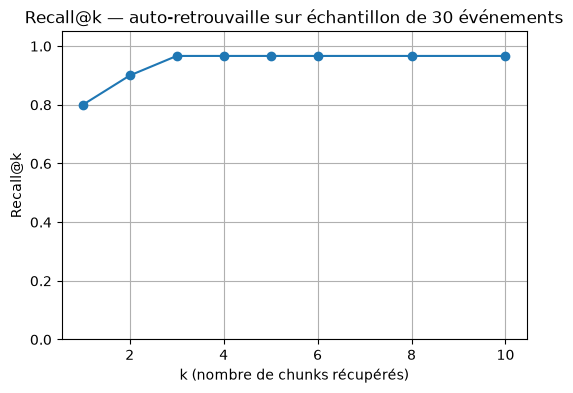

In [42]:
# Visualisation du recall@k pour déterminer nb de k adequat pour le retriever
import random
import matplotlib.pyplot as plt

random.seed(42)
k_max = 10
k_valeurs = [1, 2, 3, 4, 5, 6, 8, 10]
taille_echantillon = 30

echantillon = random.sample(chunks, k=taille_echantillon)

rangs = []
for chunk in echantillon:
    titre = chunk.metadata["titre"]
    resultats = vectorstore.similarity_search(titre, k=k_max)

    uid_source = tuple(chunk.metadata["uids"]) if isinstance(chunk.metadata["uids"], list) else chunk.metadata["uids"]

    rang_trouve = None
    for rang, r in enumerate(resultats, start=1):
        uid_r = tuple(r.metadata["uids"]) if isinstance(r.metadata["uids"], list) else r.metadata["uids"]
        if uid_r == uid_source:
            rang_trouve = rang
            break
    rangs.append(rang_trouve)

recall_par_k = {
    k: sum(1 for rang in rangs if rang is not None and rang <= k) / taille_echantillon
    for k in k_valeurs
}

for k, taux in recall_par_k.items():
    print(f"k={k:>2} -> recall@k = {taux:.0%}")

plt.figure(figsize=(6, 4))
plt.plot(list(recall_par_k.keys()), list(recall_par_k.values()), marker="o")
plt.xlabel("k (nombre de chunks récupérés)")
plt.ylabel("Recall@k")
plt.title("Recall@k — auto-retrouvaille sur échantillon de 30 événements")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

On observe que le coude est à 3 chunks, au delà de cela on ne gagne plus en pertinence et on va simplement allourdir le prompt donné au LLM et donc augmenté les couts Token pour rien.

#### Instanciation du retriever

In [43]:
#Créatio du retriever :
retriever = vectorstore.as_retriever(search_kwargs = {"k":3})

In [44]:
#test 
retriever.invoke("Quel evenement à lieu à rennes en octobre sur le thème de la peinture ?")

[Document(id='f1dcd40a-9338-4f65-9075-f1869b68708a', metadata={'uids': [93107567], 'titre': 'Extra ! Lancement de saison anniversaire !', 'ville': 'Rennes', 'quartier': "Bourg l'Évesque - La Touche - Moulin du Comte", 'code_postal': '35000', 'departement': 'Ille-et-Vilaine', 'dates': [('2026-09-20T14:00:00+02:00', '2026-09-20T19:00:00+02:00')], 'date_min': '2026-09-20T14:00:00+02:00', 'date_max': '2026-09-20T19:00:00+02:00', 'mots_cles': ['Exposition', 'Jeune public', 'Loisirs', 'Théâtre', 'Visite', 'balade'], 'url': 'https://openagenda.com/sortir-rennesmetropole/events/extra-lancement-de-saison-anniversaires', 'telephones': [], 'emails': [], 'liens': []}, page_content='Extra ! Lancement de saison anniversaire !. La Paillette prend des airs de fête pour célébrer les 20 ans du Théâtre ! En octobre 2006, La Paillette se voit confier par la Ville un nouvel équipement, le Théâtre, qui accueille tous les ans 10 000 spectateurs et spectatrices, des centaines d’artistes et des milliers d’élèv

#### Prompt systeme

In [45]:
from langchain_core.prompts import ChatPromptTemplate

prompt_systeme = """ 
#RÔLE :
Tu es un assistant spécialisé dans les événements culturels en Brtagne. 
Ton rôle est d'aider les utilisateurs à trouver des événements correspondant à leur demande, en te basant uniquement sur les informations fournies dans le contexte ci-dessous.

# OBJECTIF
Tu dois fournir des informations précises liés à l'événement ou aux événements correspondant à la demande des utilisateurs (titre de l'événement, dates, lieu, conditions d'inscriptions.

# REGLES A RESPECTER STRICTEMENT
N'utilises que les informations contenues dans les chunks que tu reçois dans le contexte fourni. N'invente jamais une information qui n'y figure pas.
Si le contexte ne contient pas l'information demandée, dis le clairement plutôt que de deviner. Par exemple : "Je n'ai pas trouvé l'information demandé dans ma base d'événement."
Si la question porte sur un sujet extérieur aux événements culturels bretons (une biographie, une ville en général, une association en dehors de ce contexte, etc.), précise poliment que cette information ne fait pas partie de ta base de connaissance, sans essayer d'y répondre à partir de connaissances générales.
Réponds toujours en français, de façon claire et concise.
Si plusieurs événements correspondent à la demande, présente-les brièvement plutôt que de n'en choisir qu'un arbitrairement.
N'hésite pas à préciser les informations pratiques utiles (dates, lieu, accessibilité, contact) quand elles sont pertinentes pour la question posée.

#EXEMPLE D'INTERACTION GUIDEE :
Utilisateur : "Quel événement culturel maritime a lieu à Concarneau en juillet ?" 
Assistant attendu : " Bonjour, en juillet, à Concarneau, vous pouvez participer aux filets bleus, dans la ville-close le 15 juillet. La participation à cet événement est gratuit et débutera à partir de 12h."


Contexte : 
{context}"""

prompt_template = ChatPromptTemplate.from_messages([
("system", prompt_systeme),
("human", "{question}"),
])

#### Assemblage de la chaine Langchain

In [46]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Création d'une fonction permettant de récupérer les chunks obtenus via le retriever et d'assembler le texte de chaque chunk (page_content donc séparation des métadatas), mais en les séparant par une ligne vide (pour compréhension par le LLM).
def formater_contexte(documents):
    return "\n\n".join(doc.page_content for doc in documents)

# Instanciation de la chaine RAG
chaine_rag = (
    #Dictonnaire dont les valeurs sont des objets Runnable, deux branches : "context", envoie la question dans le retriever 
    #pour obtenir les chunks sémantiquement pertinents et actionne ensuite formater_contexte pour les assembler.
    #La branche "question" qui elle utilise "RunnablePassthrough()" qui ne fait rien d'autre que de renvoyer l'input tel quel.
    {"context" : retriever | formater_contexte, "question" : RunnablePassthrough()} 
    | prompt_template # Injecte le dictionnaire créé dans ChatPromptTemplate qui prend en compte le prompt_systeme et la {question}.
    | llm #Injection du prompt dans le LLM qui créé un AIMessage (contenant réponse texte et métadonnées (nb de token, etc...))
    | StrOutputParser() #Permet de séparer la réponse textuel du AIMessage des métadonnées pour ne nous renvoyer que les métadonnées.
)



In [47]:
#test
reponse = chaine_rag.invoke("Quel evenement à lieu à rennes en octobre sur le thème de la peinture ?")
print(reponse)

Voici les événements à Rennes en octobre liés à la peinture :

1. **Lancement de saison anniversaire – La Paillette**
   - **Thème** : Bien que centré sur les 20 ans du Théâtre, cet événement inclut des **ateliers créatifs** (dessin, maquillage, tampons) et une exposition liée à l’histoire du lieu.
   - **Date** : 20 octobre 2026.
   - **Lieu** : Théâtre de La Paillette, 6 Rue Louis Guilloux, Rennes.
   - **Conditions** : Gratuit.
   - **Accès** : Accessible aux personnes à mobilité réduite.

2. **Journée des Arts 2026 (concours de peinture)**
   *(Note : cette édition a lieu en mai, mais voici un événement similaire en octobre si vous cherchez une autre manifestation :)*
   **À noter** : Aucune autre manifestation de peinture en octobre n'est explicitement mentionnée dans le contexte fourni. Si vous souhaitez des suggestions en dehors de ce contexte, je ne peux pas les fournir.

Pour le thème de la peinture, le **concours de l'Atelier du Thabor** (mai) reste le seul événement lié à la

Après avoir créer le jeu de Q&A, nous allons les faire passer dans la chaîne RAG Langchain pour voir si les réponses obtenues sont pertinentes et si les chunks utilisés sont correctes.

In [48]:
import pandas as pd
from langchain_core.messages import BaseMessage

df_testset = pd.read_csv("../data/qa_testset.csv")

resultats = []

for _, row in df_testset.iterrows():
    question = row["question"]

    # Réponse générée par la chaîne complète
    reponse = chaine_rag.invoke(question)
    reponse_texte = reponse.content if isinstance(reponse, BaseMessage) else str(reponse)

    # Chunks récupérés par le retriever, pour analyse (contexte utilisé par le LLM)
    documents = retriever.invoke(question)
    chunks_texte = "\n---\n".join(doc.page_content for doc in documents)

    resultats.append({
        "question": question,
        "reponse_reference": row["reponse_reference"],
        "categorie": row["categorie"],
        "reponse_generee": reponse_texte,
        "chunks_recuperes": chunks_texte,
    })
    print(f"OK : {question[:60]}...")

df_resultats = pd.DataFrame(resultats)
df_resultats.to_csv("../data/qa_results.csv", index=False)
print(f"\n{len(df_resultats)} résultats écrits dans data/qa_results.csv")

OK : À quelle heure et où a lieu la "Lecture à l'heure du goûter"...
OK : Quand se déroule le "Fest deizh" à Saint-M'Hervé ?...
OK : Quel est le tarif du spectacle de "Fêtez la Bretagne à Pont ...
OK : À quelle adresse et quel jour a lieu "Fougères fête la Breta...
OK : Sur quelle période s'étale "Brest La Fest'Yves 2026" ?...
OK : Y a-t-il un événement autour de la danse bretonne dans les C...
OK : Quels événements en Ille-et-Vilaine proposent de la musique ...
OK : Existe-t-il un événement accessible aux personnes à mobilité...
OK : Quel événement combine langue bretonne et spectacle musical ...
OK : Quel événement gratuit et familial est prévu pour les jeunes...
OK : Quels événements de la Fête de la Bretagne sont prévus à Nan...
OK : Y a-t-il une journée de recrutement dans le secteur culturel...
OK : Quel événement autour de la Bretagne est prévu en 2028 ?...

13 résultats écrits dans data/qa_results.csv


In [49]:
# Cherche les chunks liés aux 3 événements "handicap moteur" vus dans les résultats
for i, chunk in enumerate(chunks):
    if "2026-04-28" in chunk.page_content or "2026-06-30" in chunk.page_content or "2026-05-07" in chunk.page_content:
        print(f"--- Chunk {i} (longueur: {len(chunk.page_content)} caractères) ---")
        print(chunk.page_content)
        print()

--- Chunk 96 (longueur: 1041 caractères) ---
Atelier 2tonnes - Beaulieu - INSA - 07/05. En groupe, venez relever le défi “2tonnes” en jouant à ce jeu sérieux. 3h30 d’atelier où se succèdent quiz et simulation d’actions individuelles et collectives pour atteindre l’objectif de réduction de notre empreinte carbone. Destiné à tous les publics : des simples curieux qui veulent en savoir plus jusqu'aux engagé.es, en passant par celles et ceux qui ne demandent qu’à agir. A l’issu de cet atelier, les participant.e.s ressortent avec une vision plus claire et des idées précises de leviers qui peuvent faire basculer la situation. ------------- Offre d'ateliers ouverts pour des groupes de 5 à 14 participant.e.s. Animés par des étudiants et personnels volontaires de l'Université de Rennes. Pour en savoir plus sur l'atelier : https://www.2tonnes.org/atelier-2tonnes Catégories : atelier, 2tonnes, INSA Rennes. Lieu : INSA Rennes, INSA Rennes. Dates : le 2026-05-07. Conditions : Gratuit sur inscriptio

In [50]:
longueurs = [len(t) for t in textes_a_vectoriser]

print("nombre d'événements :", len(longueurs))
print("min :", min(longueurs), "max :", max(longueurs))
print("moyenne :", sum(longueurs) / len(longueurs))
print("nombre d'événements > 2000 caractères :", sum(1 for l in longueurs if l > 2000))
print("nombre d'événements > 4000 caractères :", sum(1 for l in longueurs if l > 4000))

nombre d'événements : 1651
min : 227 max : 7531
moyenne : 1054.6686856450635
nombre d'événements > 2000 caractères : 110
nombre d'événements > 4000 caractères : 9


Ajout de l'évaluation manuelle (correcte / partielle / incorrecte) et sa justification
au fichier data/qa_results.csv, sur la base de l'analyse qualitative faite question
par question sur le dernier run (sans troncature).

In [ ]:
import pandas as pd
 
df = pd.read_csv("../data/qa_results.csv")
 
# Évaluations dans le même ordre que qa_testset.csv / qa_results.csv
evaluations = [
    {
        "evaluation_manuelle": "correcte",
        "justification": "Date, heure, lieu, âge et entrée libre conformes à la réponse de référence.",
    },
    {
        "evaluation_manuelle": "partielle",
        "justification": "Faits corrects (date, heure, lieu) mais formulation contradictoire : "
                          "dit que l'événement n'a pas lieu à Saint-M'Hervé avant de donner "
                          "une adresse à Saint-M'Hervé.",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Tarif et conditions gratuit/payant conformes à la référence.",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Date, lieu et mention du 3F en soirée conformes à la référence.",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Période et horaires conformes à la référence.",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Événement de référence (Pléneuf-Val-André) correctement identifié avec "
                          "les bons horaires ; les mentions secondaires sont formulées avec "
                          "prudence, sans erreur de département cette fois.",
    },
    {
        "evaluation_manuelle": "partielle",
        "justification": "Le Gouel Breizh de Fougères est correctement identifié comme étant en "
                          "Ille-et-Vilaine, mais le Fest deizh de Saint-M'Hervé (également valide) "
                          "n'est pas mentionné.",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Randorade au Faou est un événement réel et accessible dans le Finistère ; "
                          "réponse valide même si différente de la référence choisie (Pont l'Abbé).",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Pont l'Abbé correctement identifié avec les bonnes infos ; la Soirée "
                          "kabyle-bretonne est mentionnée avec sa date exacte, sans confusion "
                          "cette fois.",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Les deux événements proposés sont réellement gratuits, familiaux et en "
                          "Ille-et-Vilaine, même si différents de la référence choisie (Lecture à "
                          "l'heure du goûter).",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Refus honnête, aucun événement à Nantes inventé.",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Refus honnête ; mentionne une journée numérique proche sans prétendre "
                          "qu'elle correspond à la demande.",
    },
    {
        "evaluation_manuelle": "correcte",
        "justification": "Refus honnête, propose des alternatives 2026 sans confondre les dates.",
    },
]
 
assert len(evaluations) == len(df), (
    f"{len(evaluations)} évaluations pour {len(df)} lignes dans qa_results.csv "
    "— vérifie que l'ordre des questions n'a pas changé."
)
 
df_eval = pd.DataFrame(evaluations)
df["evaluation_manuelle"] = df_eval["evaluation_manuelle"]
df["justification"] = df_eval["justification"]
 
df.to_csv("data/qa_results.csv", index=False)
 
print(df["evaluation_manuelle"].value_counts())
print(f"\n{len(df)} lignes mises à jour dans data/qa_results.csv")
 

evaluation_manuelle
correcte     11
partielle     2
Name: count, dtype: int64

13 lignes mises à jour dans data/qa_results.csv


Calcule les métriques automatiques (score de similarité par embeddings + Exact Match)
sur data/qa_results.csv (déjà enrichi de evaluation_manuelle / justification),
et affiche une synthèse par catégorie de question.

In [53]:
import os
import re
import string
import unicodedata

import numpy as np
import pandas as pd
from mistralai.client import Mistral
from dotenv import load_dotenv

load_dotenv()
API_KEY_MISTRAL = os.getenv("API_KEY_MISTRAL")
client = Mistral(api_key=API_KEY_MISTRAL)

df = pd.read_csv("data/qa_results.csv")

# --- 1. Score de similarité (embeddings mistral-embed + cosinus) ---

textes_a_embedder = list(df["reponse_generee"]) + list(df["reponse_reference"])

reponse = client.embeddings.create(model="mistral-embed", inputs=textes_a_embedder)
vecteurs = np.array([e.embedding for e in reponse.data])

n = len(df)
vecteurs_generees = vecteurs[:n]
vecteurs_reference = vecteurs[n:]


def similarite_cosinus(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


df["score_similarite"] = [
    similarite_cosinus(vecteurs_generees[i], vecteurs_reference[i]) for i in range(n)
]

# --- 2. Exact Match (comparaison normalisée, à titre indicatif) ---


def normaliser(texte):
    texte = str(texte).lower().strip()
    texte = unicodedata.normalize("NFKD", texte).encode("ascii", "ignore").decode("ascii")
    texte = texte.translate(str.maketrans("", "", string.punctuation))
    texte = re.sub(r"\s+", " ", texte)
    return texte


df["exact_match"] = df.apply(
    lambda row: normaliser(row["reponse_generee"]) == normaliser(row["reponse_reference"]),
    axis=1,
)

df.to_csv("data/qa_results.csv", index=False)

# --- 3. Synthèse ---

print("=== Score de similarité moyen par catégorie ===")
print(df.groupby("categorie")["score_similarite"].mean().round(3))

print("\n=== Exact Match (nombre de True) ===")
print(df["exact_match"].value_counts())

print("\n=== Taux de réponses 'correcte' par catégorie (évaluation manuelle) ===")
print(
    df.groupby("categorie")["evaluation_manuelle"]
    .apply(lambda s: (s == "correcte").mean())
    .round(2)
)

print(f"\n{n} lignes mises à jour dans data/qa_results.csv")

=== Score de similarité moyen par catégorie ===
categorie
factuelle_simple    0.881
hors_perimetre      0.818
multi_critere       0.845
Name: score_similarite, dtype: float64

=== Exact Match (nombre de True) ===
exact_match
False    13
Name: count, dtype: int64

=== Taux de réponses 'correcte' par catégorie (évaluation manuelle) ===
categorie
factuelle_simple    0.8
hors_perimetre      1.0
multi_critere       0.8
Name: evaluation_manuelle, dtype: float64

13 lignes mises à jour dans data/qa_results.csv
